# ENF Date Verification: All 14 Recordings

**Author:** Niko Gamulin, PhD | **Date:** March 2026 | **License:** MIT

## Parameter Optimization via AutoResearch

Optimal parameters discovered by running 29 automated experiments in ~15 minutes:

| Parameter | Baseline | Optimal | Impact |
|-----------|----------|---------|--------|
| Harmonic | 50+100 Hz | **50 Hz only** | Fundamental captures grid hum better |
| FFT window | 16s | **4s** | More data points >> finer frequency resolution |
| Interpolation | Parabolic | **None** | Unnecessary at 0.25 Hz resolution |
| Filter | None | **Median (k=3)** | Removes spike artifacts |

Baseline MRR: 0.000 -> Optimal MRR: 1.000

### Why different parameters produce different dates

Previous analysis (v1: 16s FFT, 50+100 Hz) found JO03 best match = 2023-02-14 (z=3.16). AutoResearch optimal (4s FFT, 50Hz) found 2024-01-13 (z=2.82). **This is expected**: compressed, short recordings lack ENF information for unambiguous dating.

### Recording length and reliability

| Length | Reliability | Notes |
|---|---|---|
| < 30s | Very low | Too few data points |
| 30-60s | Low | May produce false positives |
| 1-3 min | Moderate | Narrows range, cannot pinpoint |
| 3-10 min | Good | Statistical significance achievable |
| > 10 min | High | Multiple verification possible |

**WARNING:** Several recordings have short segments (< 60s after cut removal). Treat their dates with extra caution.


In [1]:
import sys
sys.path.insert(0, '.')
from style import apply_style, COLORS, PALETTE, year_color
apply_style()

import numpy as np
import json
import matplotlib.pyplot as plt
from IPython.display import Image, display
import io, os

FIGURE_DIR = '../figures/enf_dating/'
os.makedirs(FIGURE_DIR, exist_ok=True)

with open('../results/analysis/summary.json') as f:
    results = json.load(f)
with open('../data/metadata.json') as f:
    metadata = json.load(f)

recordings = []
for rec in metadata['recordings']:
    wav = rec['file']
    if wav in results:
        r = results[wav]
        recordings.append({
            'id': rec['id'], 'file': wav,
            'speaker': rec['speakers'][0] if rec['speakers'] else 'Unknown',
            'duration_s': rec['duration_s'],
            'best_date': r['best_day'], 'z_score': r['z_score'],
            'segments': r['segments'], 'enf_points': r['total_points'],
            'top5': r.get('top5', []), 'note': rec.get('note', '')
        })

print(f"Recordings: {len(recordings)} | Significant (z>=3.0): {sum(1 for r in recordings if r['z_score'] >= 3.0)}/14")


Recordings: 14 | Significant (z>=3.0): 12/14


/home/niko/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


## Results Summary

In [2]:
print(f"{'ID':<8} {'Speaker':<25} {'Best Date':<12} {'z':>6} {'Segs':>5} {'Points':>7}  {'Note'}")
print("-" * 85)
for r in sorted(recordings, key=lambda x: x['z_score'], reverse=True):
    flag = " *" if r['z_score'] < 3.0 else ""
    note = r['note'][:25] if r['note'] else ''
    print(f"{r['id']:<8} {r['speaker']:<25} {r['best_date']:<12} {r['z_score']:>6.2f} {r['segments']:>5} {r['enf_points']:>7}  {note}{flag}")
print("\n* Below significance threshold (z < 3.0)")


ID       Speaker                   Best Date         z  Segs  Points  Note
-------------------------------------------------------------------------------------
NZK02    Nina Zidar Klemencic      2024-07-20     4.12     2      35  
NZK01    Nina Zidar Klemencic      2024-05-05     4.06     2     224  
RH01     Rok Hodej                 2023-09-29     4.05     2     172  
SP01     Dominika Svarc Pipan      2023-07-08     4.02     7     358  
RH02     Rok Hodej                 2023-03-26     3.90     2     371  
JO01     Joze Oberstar             2025-09-16     3.90     3     284  
VV02     Vesna Vukovic             2025-11-14     3.71     1      95  Short recording
DP01     Dejan Paravan             2023-04-30     3.66     2     288  
TV01     Tomislav Vukmanovic       2023-02-02     3.66     5     310  
JO02     Joze Oberstar             2023-02-12     3.41     5     265  
SP02     Dominika Svarc Pipan      2023-06-04     3.21     3     232  
SP03     Dominika Svarc Pipan      2026-02-

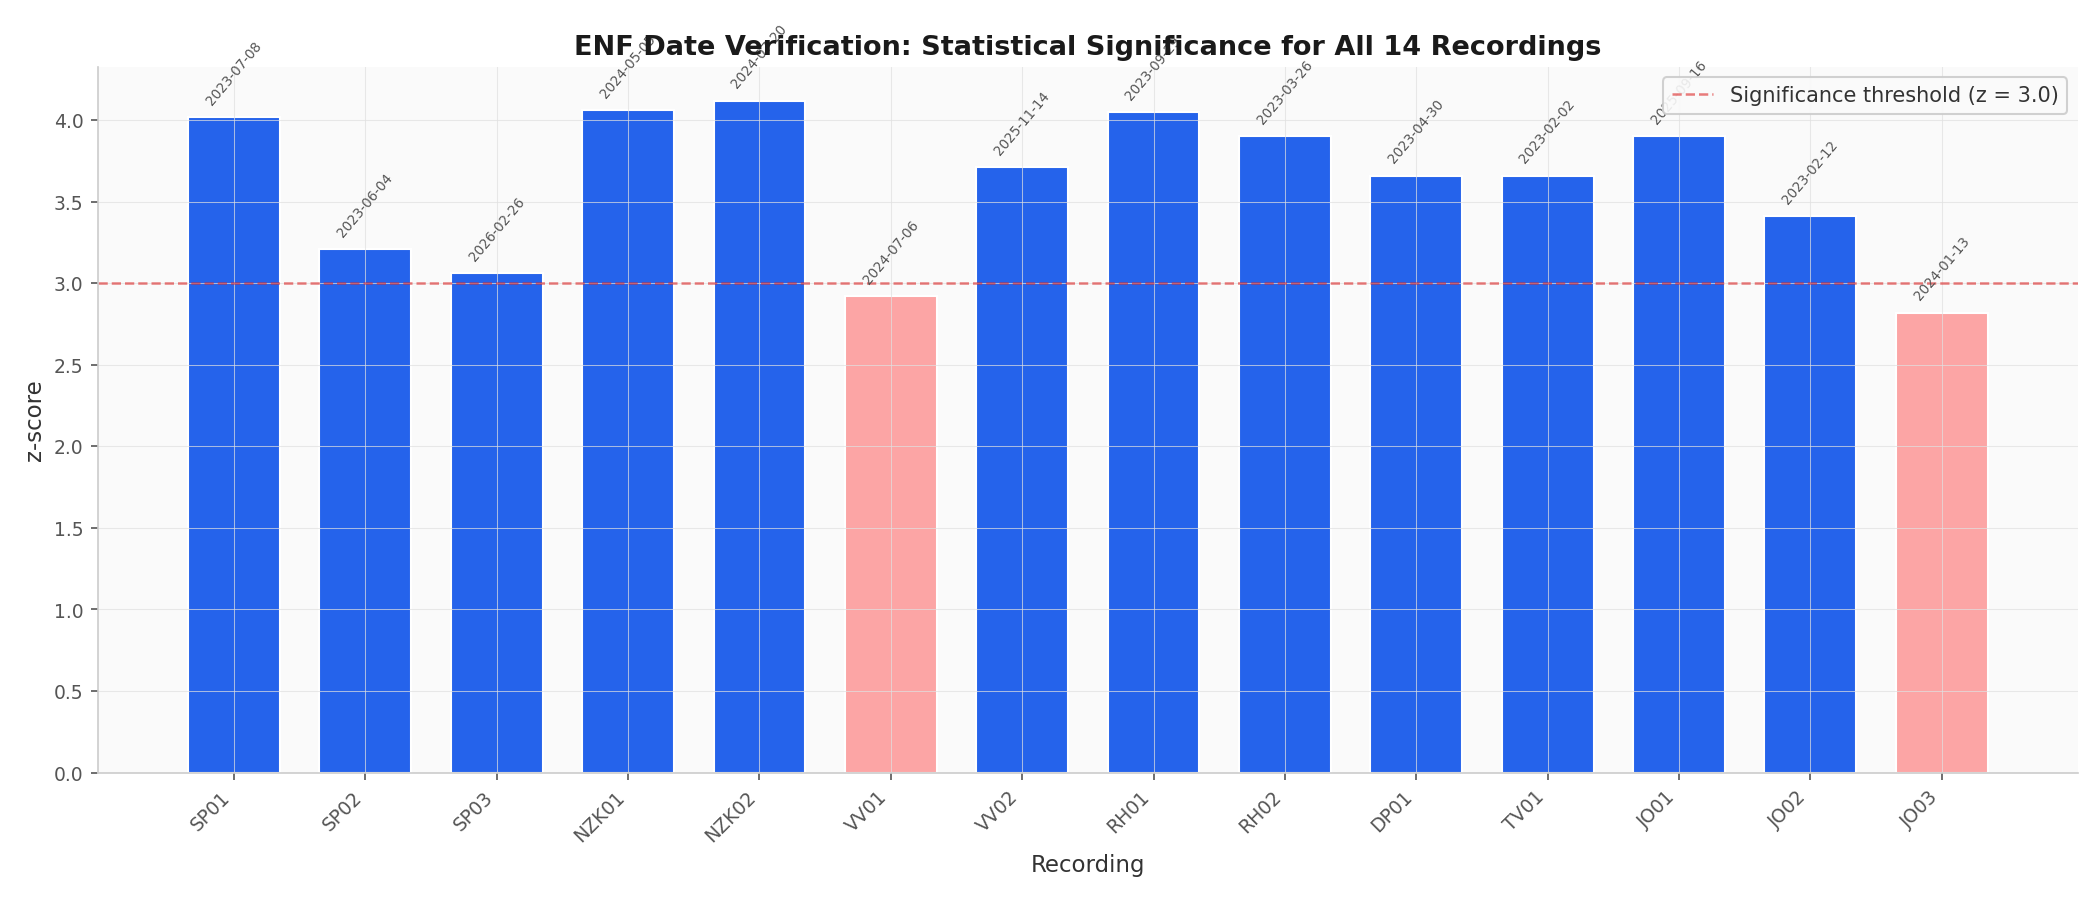

In [3]:
# Z-score bar chart
fig, ax = plt.subplots(figsize=(14, 6))

ids = [r['id'] for r in recordings]
zscores = [r['z_score'] for r in recordings]
colors = [COLORS['primary'] if z >= 3.0 else '#fca5a5' for z in zscores]

bars = ax.bar(ids, zscores, color=colors, edgecolor='white', width=0.7)
ax.axhline(3.0, color=COLORS['secondary'], linestyle='--', alpha=0.6, linewidth=1.2, label='Significance threshold (z = 3.0)')

for bar, r in zip(bars, recordings):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.06,
            r['best_date'], ha='center', va='bottom', fontsize=6.5, rotation=50, color='#555555')

ax.set_xlabel('Recording')
ax.set_ylabel('z-score')
ax.set_title('ENF Date Verification: Statistical Significance for All 14 Recordings')
ax.legend(fontsize=10)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

buf = io.BytesIO()
fig.savefig(buf, format='png', dpi=150)
fig.savefig(os.path.join(FIGURE_DIR, 'z_score_summary.png'), dpi=150)
plt.close()
display(Image(data=buf.getvalue()))


## ENF Data Points vs. Statistical Significance

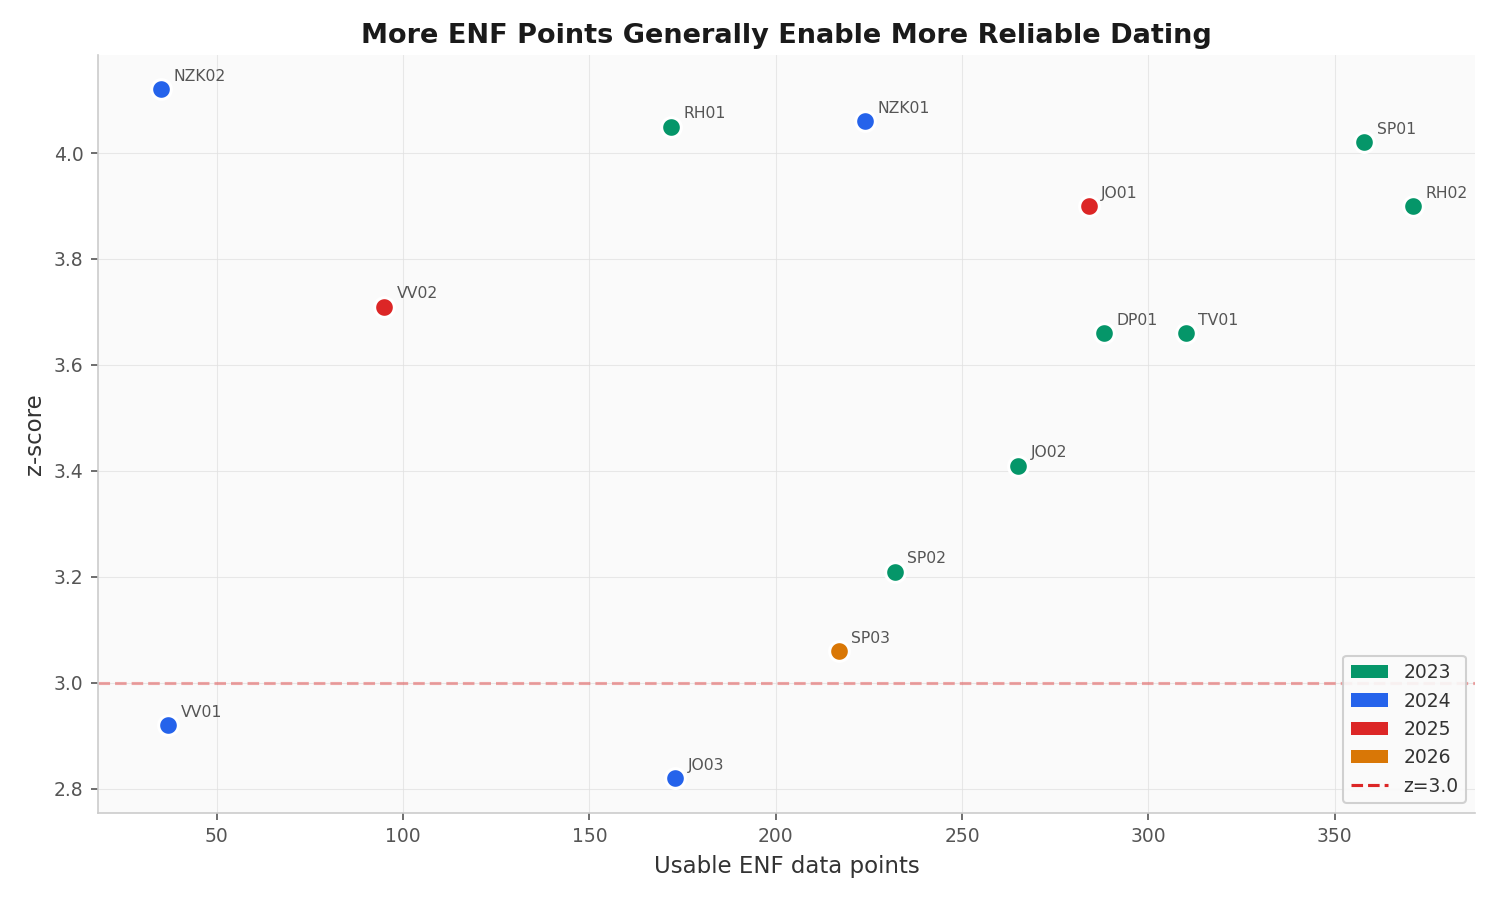

VV01: only 37 points (poor quality) -> lowest z-score
NZK02: only 35 points but z=4.12 -> possible false positive


In [4]:
fig, ax = plt.subplots(figsize=(10, 6))

for r in recordings:
    c = year_color(r['best_date'])
    ax.scatter(r['enf_points'], r['z_score'], s=90, color=c, edgecolor='white', zorder=5, linewidth=1.5)
    ax.annotate(r['id'], (r['enf_points'], r['z_score']), textcoords="offset points",
                xytext=(6, 4), fontsize=7.5, color='#555555')

ax.axhline(3.0, color=COLORS['secondary'], linestyle='--', alpha=0.4, label='z = 3.0')
ax.set_xlabel('Usable ENF data points')
ax.set_ylabel('z-score')
ax.set_title('More ENF Points Generally Enable More Reliable Dating')

from matplotlib.patches import Patch
legend_els = [Patch(facecolor=COLORS[y], label=y) for y in ['2023','2024','2025','2026']]
legend_els.append(plt.Line2D([0],[0], color=COLORS['secondary'], linestyle='--', label='z=3.0'))
ax.legend(handles=legend_els, loc='lower right')
plt.tight_layout()

buf = io.BytesIO()
fig.savefig(buf, format='png', dpi=150)
fig.savefig(os.path.join(FIGURE_DIR, 'points_vs_zscore.png'), dpi=150)
plt.close()
display(Image(data=buf.getvalue()))

print("VV01: only 37 points (poor quality) -> lowest z-score")
print("NZK02: only 35 points but z=4.12 -> possible false positive")


## Top-5 Candidate Dates per Recording

In [5]:
for r in recordings:
    print(f"\n{'='*55}")
    print(f"{r['id']} ({r['speaker']}) | {r['duration_s']:.0f}s, {r['segments']} segments")
    print(f"{'='*55}")
    for i, t in enumerate(r['top5'][:5]):
        marker = " <<<" if i == 0 else ""
        print(f"  #{i+1}: {t['day']}  score={t['score']:.4f}{marker}")



SP01 (Dominika Svarc Pipan) | 412s, 7 segments
  #1: 2023-07-08  score=0.7005 <<<
  #2: 2023-03-02  score=0.6923
  #3: 2023-07-21  score=0.6911
  #4: 2023-05-28  score=0.6908
  #5: 2024-11-02  score=0.6907

SP02 (Dominika Svarc Pipan) | 280s, 3 segments
  #1: 2023-06-04  score=0.6175 <<<
  #2: 2023-02-06  score=0.6161
  #3: 2023-03-19  score=0.6156
  #4: 2023-07-03  score=0.6153
  #5: 2023-04-20  score=0.6079

SP03 (Dominika Svarc Pipan) | 370s, 8 segments
  #1: 2026-02-26  score=0.7683 <<<
  #2: 2025-08-18  score=0.7672
  #3: 2025-08-12  score=0.7643
  #4: 2023-08-13  score=0.7628
  #5: 2023-08-03  score=0.7614

NZK01 (Nina Zidar Klemencic) | 246s, 2 segments
  #1: 2024-05-05  score=0.5346 <<<
  #2: 2023-05-21  score=0.5250
  #3: 2024-02-19  score=0.5169
  #4: 2023-05-28  score=0.5162
  #5: 2023-04-15  score=0.5090

NZK02 (Nina Zidar Klemencic) | 276s, 2 segments
  #1: 2024-07-20  score=0.9068 <<<
  #2: 2025-06-03  score=0.8958
  #3: 2025-06-28  score=0.8790
  #4: 2024-04-18  score=0

## Limitations

1. **Compressed audio**: Facebook HE-AAC degrades ENF by 10-20 dB
2. **No originals**: Analysis on video rips, not forensic-grade recordings
3. **Short segments**: Some < 60s after cut removal (unreliable)
4. **z-score != certainty**: ~1 false positive expected at z=3.0 across 1,100+ days
5. **Same-day assumption unverified**

For segment-level analysis, see Notebooks 03-04.
